In [1]:
import numpy as np
import rebound
import matplotlib.pyplot as plt
import os
import pandas as pd
from datetime import datetime

os.chdir('../src/')

from prop_elem import *
from sbdynt import *

# Computing Proper Elements Using Custom Inputs

While many users will be interested in primarily just running the default TNO and asteroid analysis suite provided by the ``run_tno`` and ``run_asteroid`` functions, many users will be interested in computing the proper elements without running the machine learning and chaos indicators. 

In addition, users may want to specify other parameters, such as the length of integration, output cadence, or the planets included in the simulation.
SBDynT allows for custom runs to produce proper elements easily using the underying functions which are called directly by the ``run_tno`` and ``run_asteroid`` functions, which we will describe here. 

## Initializing Integration

To compute synthetic proper elements, we need to produce an initial REBOUND simulation of the Solar System accompanied by the particles of interest. To initialize the default simulations for TNO's and asteroid, SBDynT provides the ``setup_default_tno_integration`` and ``setup_default_asteroid_integration`` functions. 

This function does not require the small_body class meaning a user may use these functions to initialize objects outisde of the small_body class ecosystem if they wish. 

``initialize_simulation(planets=['all'], des=None, clones=0, cloning_method='Gaussian', datadir='', saveic=False, logfile=False, save_sbdb=False)``
``returns flag, epoch, sim, weights``

The primary inputs required by the user to include will be the ``planets`` and ``des``variables. The ``clones` and ``cloning_methods`` variables are primarily of interest for users wishing the run the machine_learning analysis or some chaos indicator analysis, while the rest of the variables are primarily bookkeeping parameters which are relevant to every analysis.


Below, we initialize simulations for the asteroid ``(1) Ceres`` and the TNO ``(15760) Albion``. using the recommended planets for each type of object. 

#####

In [2]:
flag1, epoch1, sim1 = initialize_simulation(planets=['inner'], des='Ceres', clones=0,  datadir='../example-notebooks/advanced_example_sims', saveic=True, logfile=True, save_sbdb=True)
flag2, epoch2, sim2 = initialize_simulation(planets=['outer'], des='Albion', clones=0, datadir='../example-notebooks/advanced_example_sims', saveic=True, logfile=True, save_sbdb=True)

We can see that in the example_sims directory, there are now several files that have been populated, including a log file for the current date, a pkl file outling the exact query made to JPL Horizons, and initial condition REBOUND simulations which are equivalent to the sim1 and sim2 simulations we have saved as variables above. 
 

## Running the Integration

Now that our simulations are initialized, we can run the integration using the ``run_simulation`` function.

```rflag, sim = integrate_for_pe(sim, des=None, archivefile=None,datadir=None, logfile=None,tmax=10e6,tout=500., direction='bf')```
                                       

We show examples integrating both Ceres and Eris, setting tmax for much shorter timescales, but sufficient to capture the slowest planetary secular frequencies.

In [3]:
rflag1, sim1 = integrate_for_pe(sim1, des='Ceres', datadir='../example-notebooks/advanced_example_sims', logfile=True,tmax=5e6,tout=500.)
rflag2, sim2 = integrate_for_pe(sim2, des='Albion', datadir='../example-notebooks/advanced_example_sims', logfile=True,tmax=50e6,tout=5000.)


## Reading the Simulation

Users familiar with Rebound Simulationarchives may be able to read in the orbital elements from the completed simulations themsevles, but SBDynT provides a useful function for reading in the orbital elements for the planets, the small body, and any included clones, while also sorting the orbital elements by time, and handling complex cases, such as multi-resolution simulations, like those used in the machine learning analyses.

```read_archive_for_pe(des, clones=3, datadir='',archivefile='', logfile='', object_type= None)```

In [2]:
pr_flag1, time1, sb_elems1, planet_elems1, clone_elems1, small_planets_flag1 =  read_archive_for_pe('Ceres', clones=0, datadir='../example-notebooks/advanced_example_sims', logfile=True, object_type= None)
pr_flag2, time2, sb_elems2, planet_elems2, clone_elems2, small_planets_flag2 =  read_archive_for_pe('Albion', clones=0, datadir='../example-notebooks/advanced_example_sims', logfile=True, object_type= None)

# Computing the Synthetic Proper Elements

To compute synthetic proper elements for the small_body the typical user will simply call the ``compute_proper`` function, as shown below.
The function call will print the comptued proper elements out; additional outputs, such as the uncertianties, are saved to the particle and can be retrieved directly. 

In [3]:
pflag1, pe1 = calc_proper_elements(des='Ceres', times = time1, sb_elems = sb_elems1, planet_elems = planet_elems1, small_planets_flag = small_planets_flag1, output_arrays=True)
pflag2, pe2 = calc_proper_elements(des='Albion', times = time2, sb_elems = sb_elems2, planet_elems = planet_elems2, small_planets_flag = small_planets_flag2, output_arrays=True)

### Ceres Outputs

In [5]:
print('Secular Planetary Frequencies: ',pe1.planet_freqs)

print('\nProper Elements: ', pe1.proper_elements)
print('\nProper Errors: ', pe1.proper_errors)

print('\nMean Elements: ', pe1.mean_elements)
print('\nOsculating Elements: ', pe1.osculating_elements)

Secular Planetary Frequencies:  {'g5': 3.197602097897763e-06, 'g6': 2.179385204201029e-05, 'g7': 2.399276216256742e-06, 'g8': 5.656194469807798e-07, 's6': -2.037946903590619e-05, 's7': -2.4013415222460117e-06, 's8': -6.006357347075482e-07, 'g2': 5.592791442665979e-06, 'g3': 1.358504316494986e-05, 'g4': 1.30113476965079e-05, 's3': -1.4527818390241722e-05, 's4': -1.3660926827261624e-05, 's2': -4.798727358596181e-06}

Proper Elements:  {'a': 2.763417659631133, 'e': 0.1152177539470487, 'sinI': 0.1675523216644234, 'g(rev/yr)': 4.179549235155107e-05, 's(rev/yr)': 4.573477113982301e-05, 'g("/yr)': 54.16695808761018, 's("/yr)': 59.27226339721063}

Proper Errors:  {'RMS_a': 4.739228780256329e-06, 'RMS_e': 8.877136682875389e-05, 'RMS_sinI': 6.089574235516162e-05, 'RMS_g(rev/yr)': 2.0618285406541015e-07, 'RMS_s(rev/yr)': 9.134228699965858e-05, 'RMS_g("/yr)': 0.26721297886877154, 'RMS_s("/yr)': 118.37960395155753}

Mean Elements:  {'a': 2.763417659631133, 'e': 0.1182164835359347, 'sinI': 0.1688515

### Albion Outputs

In [6]:
print('Secular Planetary Frequencies: ',pe2.planet_freqs)

print('\nProper Elements: ', pe2.proper_elements)
print('\nProper Errors: ', pe2.proper_errors)

print('\nMean Elements: ', pe2.mean_elements)
print('\nOsculating Elements: ', pe2.osculating_elements)

Secular Planetary Frequencies:  {'g5': 3.27902255000769e-06, 'g6': 2.1775561149124486e-05, 'g7': 2.3794760194953345e-06, 'g8': 5.198835857015277e-07, 's6': -2.0315603407136324e-05, 's7': -2.3089260203051444e-06, 's8': -5.399399349075224e-07}

Proper Elements:  {'a': 43.92891175117048, 'e': 0.071276059071041, 'sinI': 0.04627439092242749, 'g(rev/yr)': 3.199273708720715e-07, 's(rev/yr)': -3.200841027603593e-07, 'g("/yr)': 0.4146258726502046, 's("/yr)': -0.4148289971774256}

Proper Errors:  {'RMS_a': 1.574834139649157e-05, 'RMS_e': 0.0016554830256948832, 'RMS_sinI': 0.002658017276165329, 'RMS_g(rev/yr)': 9.677840346872439e-11, 'RMS_s(rev/yr)': 4.230674507320469e-11, 'RMS_g("/yr)': 0.0001254248108954668, 'RMS_s("/yr)': 5.482954161487328e-05}

Mean Elements:  {'a': 43.92891175117048, 'e': 0.07146729398358563, 'sinI': 0.05063928598401393, 'g(rev/yr)': 3.1681551119843147e-07, 's(rev/yr)': -2.529853003384821e-07, 'g("/yr)': 0.41059290251316716, 's("/yr)': -0.3278689492386728}

Osculating Elemen

# Using Local Simulation Data to Compute Proper Elements

Because of the input schema of the ```calc_proper_elements``` function, users are able to comptue proper elements using time arrays of orbital elements produced by other integration methods as well, as long as the inputs are given correctly. This may be helpful for users with simulation data produced using other integrators, such as Mercury, SWIFT, or ASSIST. 

We show an example here of reading in local simulation data, modifying the arrays to match the input parameters for the function, and calling the ```calc_proper_elements``` function with the inputs.

## Calling ```calc_proper_elements``` Directly

If you wish to call ```calc_proper_elements``` directly, you, the user, must provide the following inputs:

(1) ```times```          (numpy.ndarray, shape = (len(simulation))): 
    
```times``` is the time array corresponding to the orbital simulation, in units of years. 
This time array should be in increasing order*, and should have the same resolution throughout the entire array**.

(2) ```sb_elems```       (numpy.ndarray, shape = (5, len(simulation))):

```sb_elems``` contains each array of the small-body secular orbital elements, [a,e,I,omega,Omega] at the times contained in the ```times``` array. 


(3) ```planet_elems```   (dict):

```planet_elems``` is a dictionary containing the orbital arrays for each planet in the simulation. 
Each item in the dictionary is a key of the planet name, with a corresponding numpy.ndarray object with the same shape as sb_elems, shape=(5, len(simulation)).
Example: planet_elems = {'jupiter': jupiter_elems, 'saturn': saturn_elems, ...}

(4) ```small_planets_flag```   (boolean):

```small_planets_flag``` determines whether the proper element computation filters out only the giant planet frequencies, or includes the rocky planets. 

True: filters out 7 planets (venus, earth, mars, jupiter, saturn, uranus, neptune)
    
False: filters out 4 planets (jupiter, saturn, uranus, neptune)
   
    
*: Users who produce integrations for SBDynT using the machine learning functionality will have a Rebound Simulationarchive with multiple resolutions contained in the single archive. Also, using the default forwards + backwards integration will produce a Simulation archive that has both negative and positive time steps. The ```read_archive_for_pe``` function automatically handles these effects in a REBOUND archive, and returns orbital elements and a time-array that have the correct cadence and direction for proper element computation. 

**: correct values for the proper elements will still be produced if given in descending order. However, the sign on the output ```g``` and ```s``` freuqencies will be flipped.

# Using Self-Defined Planetary Frequencies

While not recommended, users may also compute proper elements without providing the planetary orbital elements. The user may do so by either providing 
(1) their own ```gs_dict```, which is a dictionary of the relevant ```g_i``` and ```s_i``` planetary frequencies, or 
(2) submitting ```None```, which will use the ```g_i``` and ```s_i``` frequencies reported by Milani and Knezevic 1994 for the giant planets, and the values for the rocky planets provided by Brouwer and van Woerkom 1950.

Note that these units should be reported in units of rev/yr.

Here is an example of running ```calc_proper_elements``` with a self-defined ```gs_dict``` equal to the 1950 analytical values reported by Brouwer and van Woerkom, and with a ```gs_dict = None```, whic automatically uses the default values provided by Milani and Knezevic 1994.

In [8]:
# Brouwer and van Woerkom 1950 Frequencies for all 7 Planets
gs_dict = {'g5': 4.29591/1296000 ,'g6': 27.77406/1296000, 'g7': 2.71931/1296000, 'g8': 0.63332/1296000, 
           's6': -25.73355/1296000, 's7': -2.90266/1296000, 's8': -0.67752/1296000,
          'g2': 7.34474/1296000, 'g3': 17.32832/1296000, 'g4': 18.00233/1296000,
          's2': -6.57080/1296000, 's3': -18.74359/1296000, 's4': -17.63331/1296000}

pflag1_new, pe1_new = calc_proper_elements(des='Ceres', times = time1, sb_elems = sb_elems1, small_planets_flag = small_planets_flag1, gs_dict = gs_dict)
pflag2_new, pe2_new = calc_proper_elements(des='Albion', times = time2, sb_elems = sb_elems2, small_planets_flag = small_planets_flag2, gs_dict = None)

### Ceres Outputs

In [9]:
print('Secular Planetary Frequencies: ',pe1_new.planet_freqs)

print('\nProper Elements: ', pe1_new.proper_elements)
print('\nProper Errors: ', pe1_new.proper_errors)

print('\nMean Elements: ', pe1_new.mean_elements)
print('\nOsculating Elements: ', pe1_new.osculating_elements)

Secular Planetary Frequencies:  {'g5': 3.3147453703703705e-06, 'g6': 2.143060185185185e-05, 'g7': 2.098233024691358e-06, 'g8': 4.886728395061728e-07, 's6': -1.985613425925926e-05, 's7': -2.239706790123457e-06, 's8': -5.227777777777778e-07, 'g2': 5.6672376543209875e-06, 'g3': 1.3370617283950618e-05, 'g4': 1.3890686728395062e-05, 's2': -5.070061728395062e-06, 's3': -1.4462646604938273e-05, 's4': -1.3605949074074075e-05}

Proper Elements:  {'a': 2.763417659631133, 'e': 0.11521775372293834, 'sinI': 0.16755388951169237, 'g(rev/yr)': 4.179549028573572e-05, 's(rev/yr)': 4.573476963829052e-05, 'g("/yr)': 54.16695541031349, 's("/yr)': 59.272261451224516}

Proper Errors:  {'RMS_a': 4.739228780256329e-06, 'RMS_e': 8.818432788961037e-05, 'RMS_sinI': 6.24332919641986e-05, 'RMS_g(rev/yr)': 2.070567678596812e-07, 'RMS_s(rev/yr)': 9.13422854981261e-05, 'RMS_g("/yr)': 0.2683455711461468, 'RMS_s("/yr)': 118.37960200557141}

Mean Elements:  {'a': 2.763417659631133, 'e': 0.1182164835359347, 'sinI': 0.1688

### Albion Outputs

In [10]:
print('Secular Planetary Frequencies: ',pe2_new.planet_freqs)

print('\nProper Elements: ', pe2_new.proper_elements)
print('\nProper Errors: ', pe2_new.proper_errors)

print('\nMean Elements: ', pe2_new.mean_elements)
print('\nOsculating Elements: ', pe2_new.osculating_elements)

Secular Planetary Frequencies:  {'g5': 3.299e-06, 'g6': 2.197e-05, 'g7': 2.398e-06, 'g8': 5.022e-07, 's6': -2.032e-05, 's7': -2.309e-06, 's8': -5.3395e-07}

Proper Elements:  {'a': 43.92891175117048, 'e': 0.071274964285181, 'sinI': 0.04627134879980843, 'g(rev/yr)': 3.199273708616711e-07, 's(rev/yr)': 3.1989635915764334e-07, 'g("/yr)': 0.41462587263672573, 's("/yr)': 0.4145856814683058}

Proper Errors:  {'RMS_a': 1.574834139649157e-05, 'RMS_e': 0.0016556699600004483, 'RMS_sinI': 0.002660221111488842, 'RMS_g(rev/yr)': 9.677841386909733e-11, 'RMS_s(rev/yr)': 6.399396592744647e-07, 'RMS_g("/yr)': 0.00012542482437435013, 'RMS_s("/yr)': 0.8293617984197064}

Mean Elements:  {'a': 43.92891175117048, 'e': 0.07146729398358563, 'sinI': 0.05063928598401393, 'g(rev/yr)': 3.1681551119843147e-07, 's(rev/yr)': -2.529853003384821e-07, 'g("/yr)': 0.41059290251316716, 's("/yr)': -0.3278689492386728}

Osculating Elements:  {'a': array([43.93250143]), 'e': array([0.06937744]), 'I': array([0.03814445]), 'o'

### Note that while mostly similar, there are very minor differences in the reported proper elements and the uncertainties when using self-defined planetary secular frequencies in these cases. 

### However, the impact of self-reported frequencies could be inflated in cases of small bodies which are really secularly resonant with a planet. Therefore, we recommend using planetary orbital element arrays when possible. 

# Other Outputs of Interest

While the typical user will primarily be interested in just the proper element outputs themselves, advanced users will find a number of helpful indicators and measures of uncertainty provided by the ``proper_element`` class, which we discuss here. 


## ``proper_indicators``

The ``proper_indicators`` variable within the ``proper_element`` class is a dictionary containing several helpful indciators related to the initial time arrays, and the filtered results of the synthetic proper element computation. 

### ``proper_indicators['Ecc Mean Flag']`` and ``proper_indicators['sinI Mean Flag']``

As discussed in Spencer et al. 2026, many small bodies experience chaotic orbital motion, or expertience secular commensurabiltiy or resonance which causes periodic orbital evolution which exceeds the length of the simulation. When this is the case, the forced motion cannot be fully separated from the proper motion of the small body, and the resulting values reported by the ``proper_elements`` dictionary should really be considered "mean" elements instead. 
If a small body is defined as having either a mean element eccentricity or inclination, the user should be aware that this object may be chaotic, or is highly commensurable with a forcing planet. In the seocnd case, a longer integration may be more successful at capturing the long-period terms during the filter.

In [15]:
print(pe1.proper_indicators['Ecc Mean Flag'], pe1.proper_indicators['sinI Mean Flag'])
print(pe2.proper_indicators['Ecc Mean Flag'], pe2.proper_indicators['sinI Mean Flag'])

False False
False False


### ``proper_indicators['Ecc Mean Indicator']`` and ``proper_indicators['sinI Mean Indicator']``

These values are the related criteria for defining a mean element is discussed in Section 2.5 of Spencer et al. 2026, which we review here. 

After filtering is first applied to the hk and pq arrays, SBDynT measures the level of remnant variability in the eccentricity and inclination arrays. This is done by taking the Fourier transform of the filtered eccentricity and inclination time arrays, and then measuring the square root of the total sum of power contained outside of the 0-bin of the FFT, divided by the length of the array. 

This value is effectively a measure of the sum of the remnant amplitudes contained within the time array, and can be considered the maximum possible amplitude of the remaining terms. 

If the filtering has successfully removed the forced terms contained in the eccentircity and incliantion time arrays due to planetary perturbations, then the amount of remnant amplitude should be very small, and will be generally relegated to noise. However, if there is significant remnant variation, then this value increases. 

Mean elements are thus defined for cases where these indicators either exceed a value of 0.01 (indicating that the amplitude of variation in that element exceeds 0.01), or where the value of these indicators divided by the proper element itself exceeds 0.1 (indicating that the remnant variabiltiy is larger than 10% of the proper element itself).

In [16]:
print(pe1.proper_indicators['Ecc Mean Indicator'], pe1.proper_indicators['sinI Mean Indicator'])
print(pe2.proper_indicators['Ecc Mean Indicator'], pe2.proper_indicators['sinI Mean Indicator'])

0.0020794489124746456 0.0017030885238109987
0.0008857395115872927 0.0016329386788297134


### ``proper_indicators['Ecc Osculating Amplitude']`` and ``proper_indicators['sinI Osculating Amplitude']``
### ``proper_indicators['Ecc Filtered Amplitude']`` and ``proper_indicators['sinI Filtered Amplitude']``

### ``proper_indicators['Distance Metric']``

# Plotting Results

It may be useful to be able to directly visualize the results of the filtering process done. Several helpful plots can be produced by calling functions directly from the ``proper_element`` class itself.

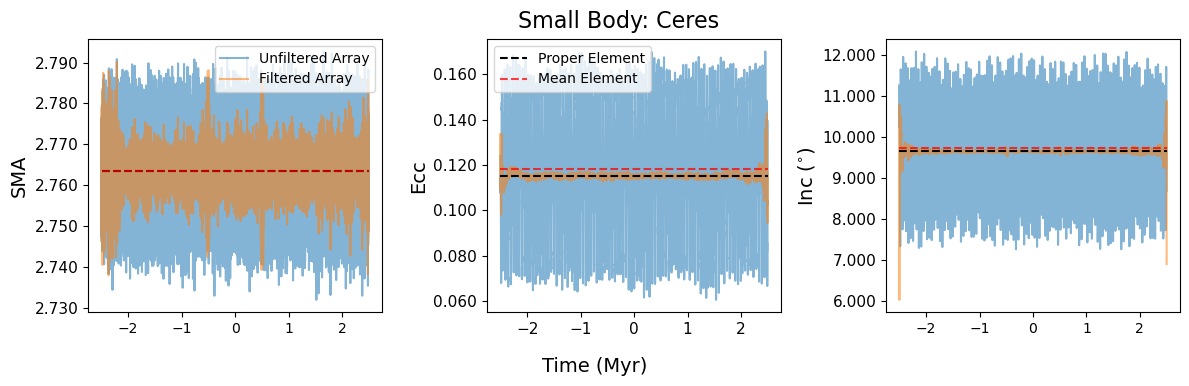

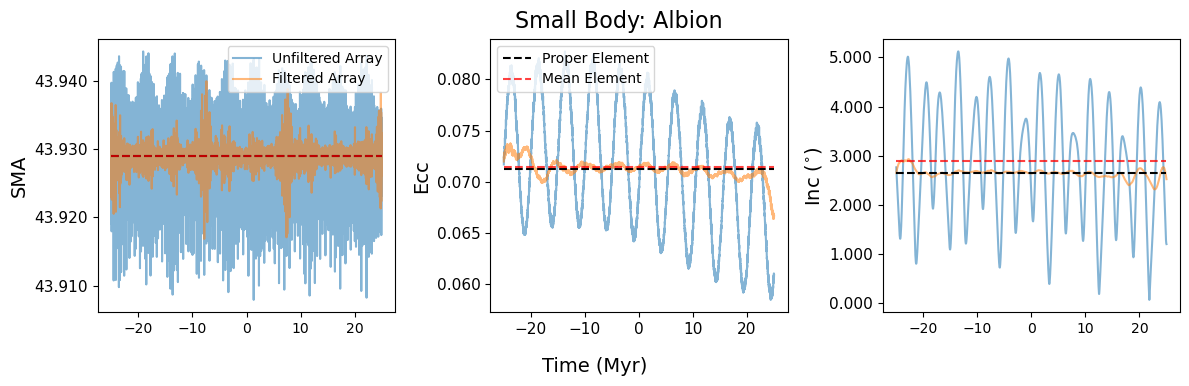

In [4]:
pe1.plot_time_arrays()
pe2.plot_time_arrays()

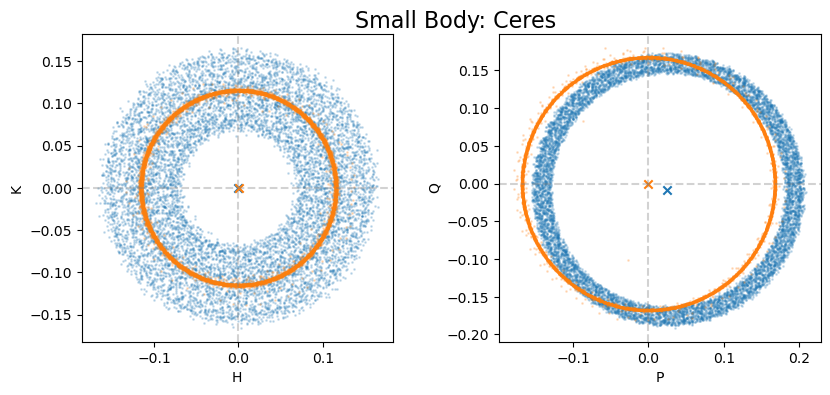

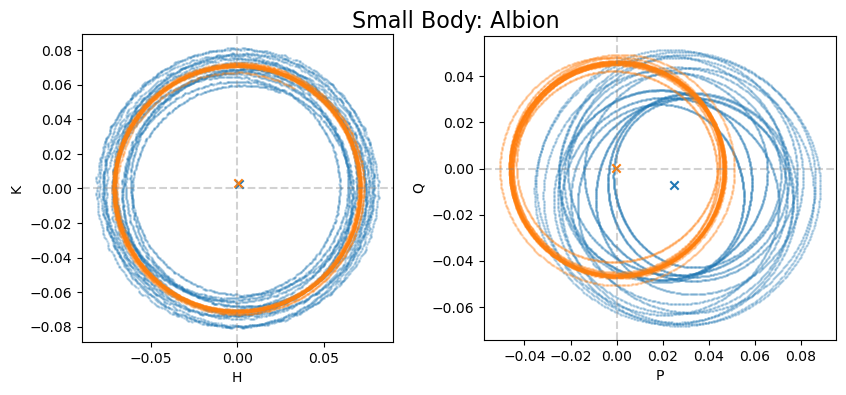

In [5]:
pe1.plot_hkpq()
pe2.plot_hkpq()

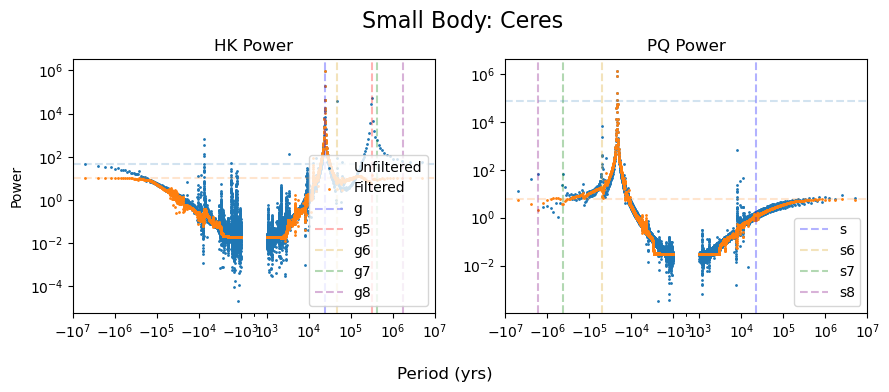

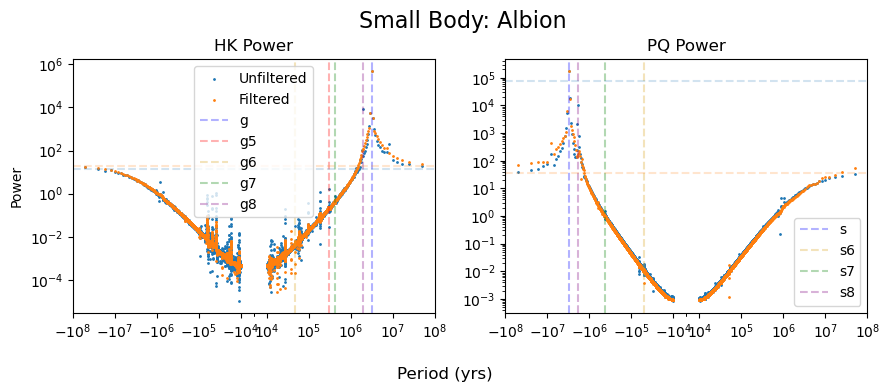

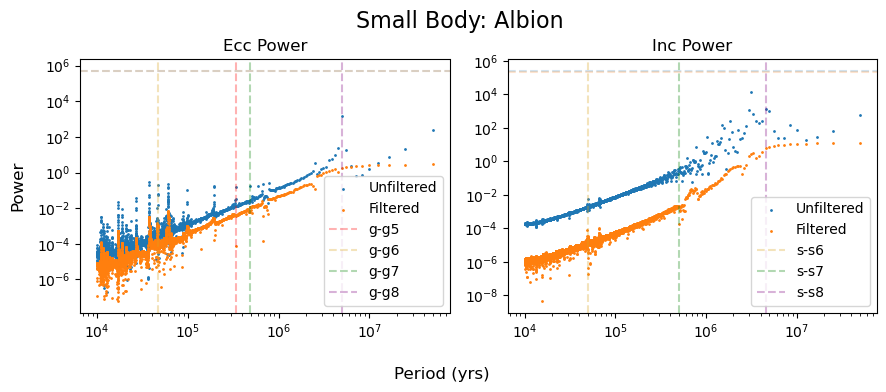

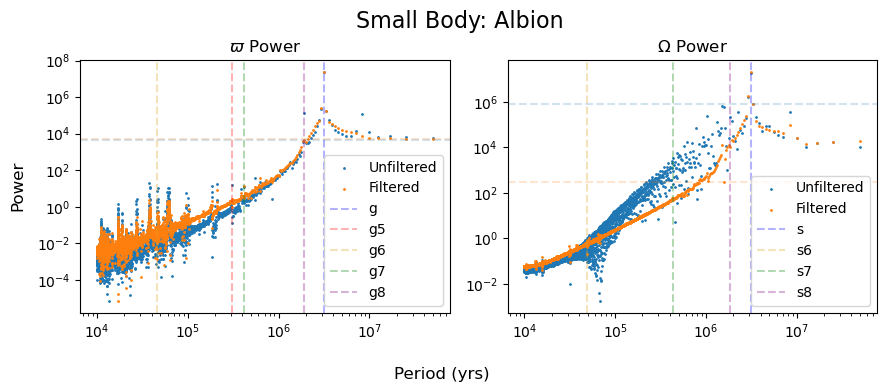

In [6]:
pe1.plot_freq_space('1')
pe2.plot_freq_space('123')


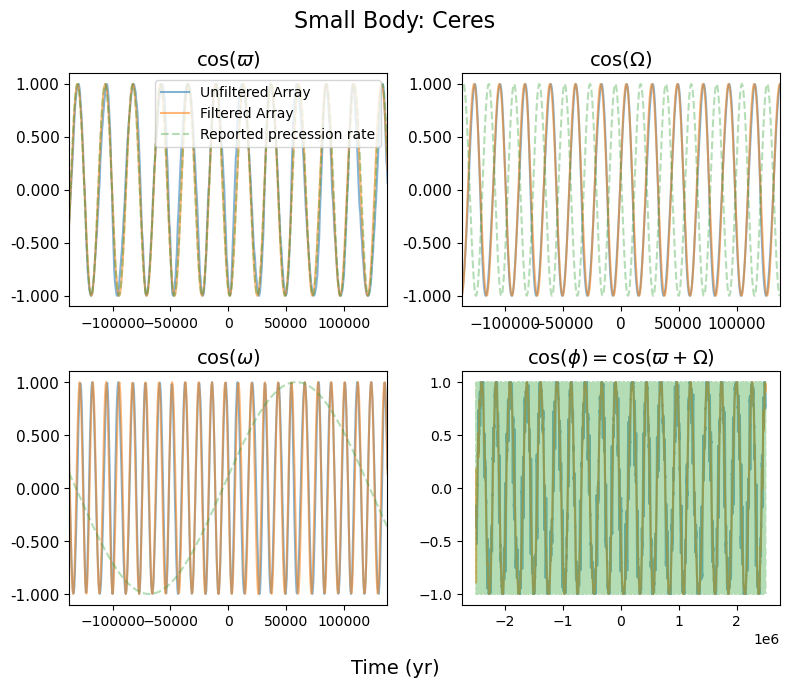

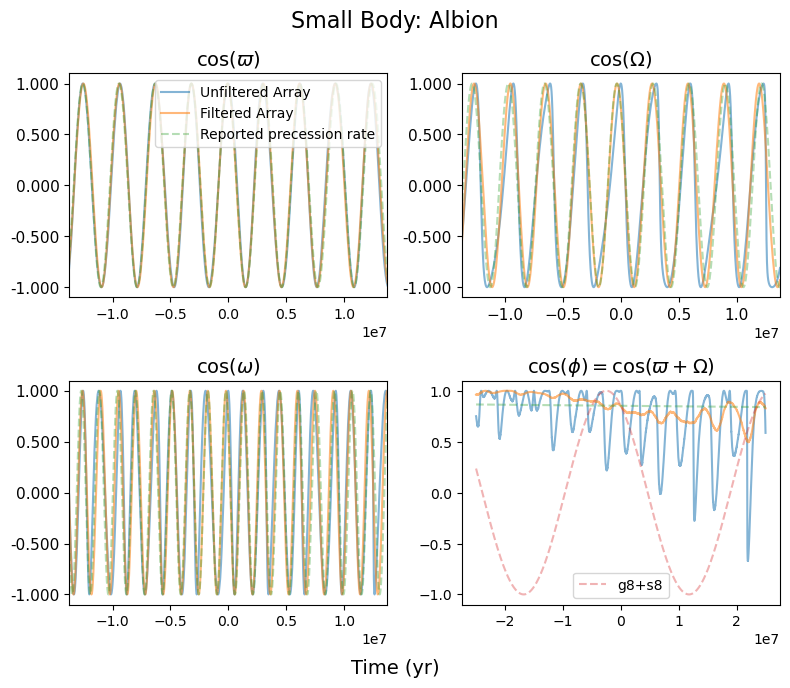

In [13]:
pe1.plot_angles(plot_cos=True)
pe2.plot_angles(plot_cos=True, ifreqs = {3: ('g8+s8', pe1.planet_freqs['g8']+pe1.planet_freqs['s8'])})

# Understanding Secularly Resonant Objects

The indicators and visualizations mentioned above can be useful for identifying objects with unique dynamics occurring within their orbital motion.

For example, identifying obejcts in secular resonance is a very relevant step to understanding the orbital motion of TNOs. We demonstrate here two examples of how the results provided by SBDynT could be used to identify an object that is very near a secular resonance, and what commensurability and occupation of a secular resonance does to the orbital motion of a small body.

We first demonstrate TNO 2019 QQ110, which is discusse din Specner et al. 2026 as being near the g8+s8 secular resonance with Neptune, causing long-period terms to strongly affect its eccentricity and inclination evolution. First, we perform a 50 Myr integration, which will struggle to fully capture the proper precession rates, due to the length of the simulation.

In [7]:
flag3, epoch3, sim3 = initialize_simulation(planets=['outer'], des='2019 QQ110', clones=0, datadir='../example-notebooks/advanced_example_sims', saveic=True, logfile=True, save_sbdb=True)
rflag3, sim3 = integrate_for_pe(sim3, des='2019 QQ110', datadir='../example-notebooks/advanced_example_sims', logfile=True,tmax=50e6,tout=5000.)

In [8]:
pr_flag3, time3, sb_elems3, planet_elems3, clone_elems3, small_planets_flag3 =  read_archive_for_pe('2019 QQ110', clones=0, datadir='../example-notebooks/advanced_example_sims', logfile=True, object_type= None)
pflag3, pe3 = calc_proper_elements(des='2019 QQ110', times = time3, sb_elems = sb_elems3, planet_elems = planet_elems3, small_planets_flag = small_planets_flag3, output_arrays=True)


In [12]:
print(len(pe1.time))
print(np.sqrt(55)/10003)

10003
0.0007413974294807221
